In [1]:
import animate as an
import makelines as ml
import numpy as np
from matplotlib import pyplot as plt
import timeit
from IPython.display import Video,display
import networkx as nx
import os
import pickle

In three dimensions, it seems that frozen spirals only exist below the Benjamin Feir line $bc<1$.

Plot the final state faces for running or complete simulations

./rdcu -s 1 -t 2000.000000 -d 0.100000 -N 128,128,128 -L 200.000000,200.000000,200.000000 -s 100 -n 2 -D1 -R scratch/3dcgle/1/5/ 

runtime: 88.564761

b=0.500000, c=1.428571
final time: 2000.000000


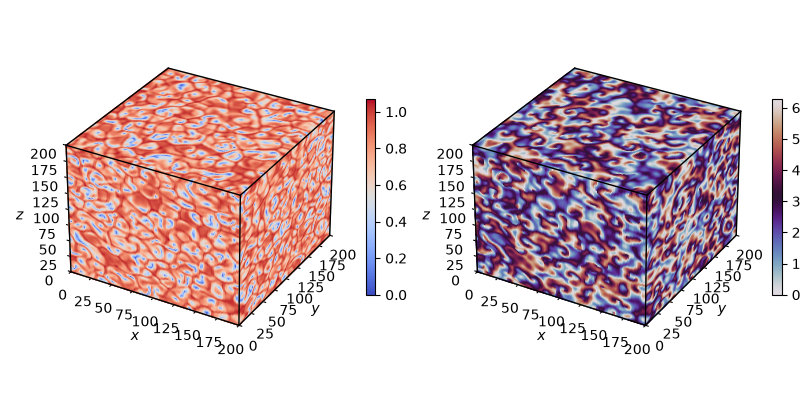

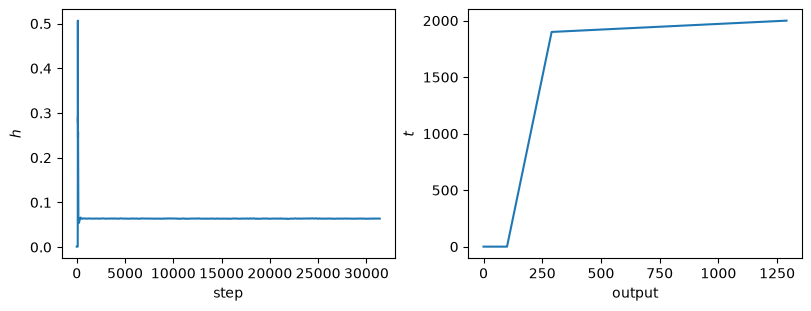

In [2]:
Ns=np.array([128,128,128])
Ls=np.array([200.,200.,200.])
N=np.prod(Ns)

filebase='scratch/3dcgle/1/5/'

file=open('%s.out'%(filebase),'r')
sts=file.readlines()
file.close()
print(sts[0])
print(sts[-1])
file=open('%scoupling.dat'%(filebase),'r')
sts=file.readlines()
file.close()
b=-float(sts[5].split(',')[0])
c=float(sts[18].split(',')[0])
print('b=%f, c=%f'%(b,c))
ys=np.fromfile('%sfs.dat'%(filebase),dtype=float)[:2*N].reshape([2]+Ns.tolist())
ts=np.fromfile('%stimes.dat'%(filebase),dtype=float)
hs=np.fromfile('%ssteps.dat'%(filebase),dtype=float)

print("final time: %f"%(ts[-1]))
faces=[[ys[:,0,:,:],ys[:,:,0,:],ys[:,:,:,0],ys[:,-1,:,:],ys[:,:,-1,:],ys[:,:,:,-1]]]
Rmax=np.max(np.linalg.norm(faces,axis=2))
lines=None
n=0

an.makeplot(n, Ns, Ls, faces=faces, lines=lines, Rmax=Rmax, show=True, save=False)

ts=np.fromfile('%stimes.dat'%(filebase),dtype=float)
hs=np.fromfile('%ssteps.dat'%(filebase),dtype=float)

plt.subplots(1,2,figsize=(8,3),layout='constrained')
plt.subplot(1,2,1)
plt.plot(hs)
# plt.yscale('log')
plt.xlabel('step')
plt.ylabel(r'$h$')
plt.subplot(1,2,2)
plt.plot(ts)
plt.xlabel('output')
plt.ylabel(r'$t$')
plt.show()

Make and plot the final state lines for running or complete simulations

100.283962785732


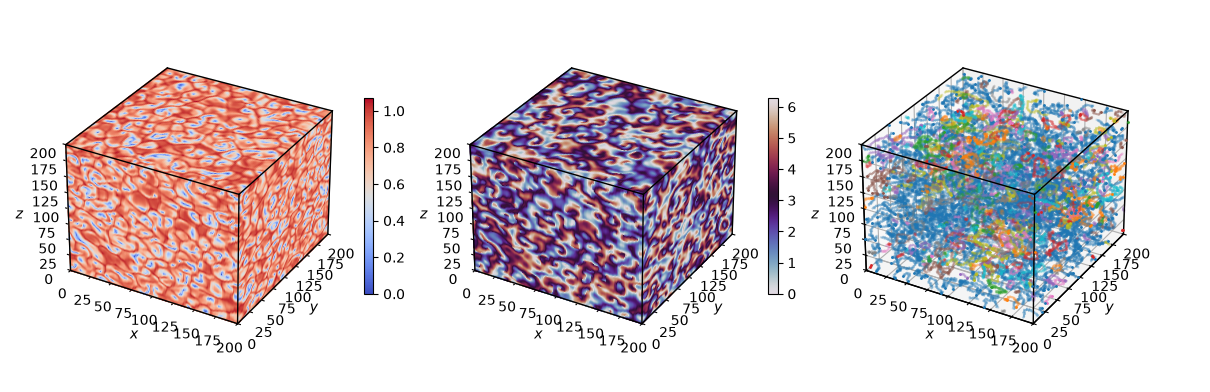

41.27473180973902


In [3]:
start=timeit.default_timer()
line=ml.savelines(0,'%sfs.dat'%(filebase),Ns,Ls,0,1024)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
an.makeplot(0, Ns, Ls, faces=faces, lines=[line], cids=[[i%len(an.colors) for i in range(len(line))]], Rmax=Rmax, show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

load the saved lines for complete simulations

In [4]:
file=open('%slines.dat'%filebase, 'rb')
lines=pickle.load(file)
file.close()

file=open('%slineids.dat'%filebase, 'rb')
ids,cids,edges=pickle.load(file)
file.close()
nt=len(lines)

plot the ancestry graph

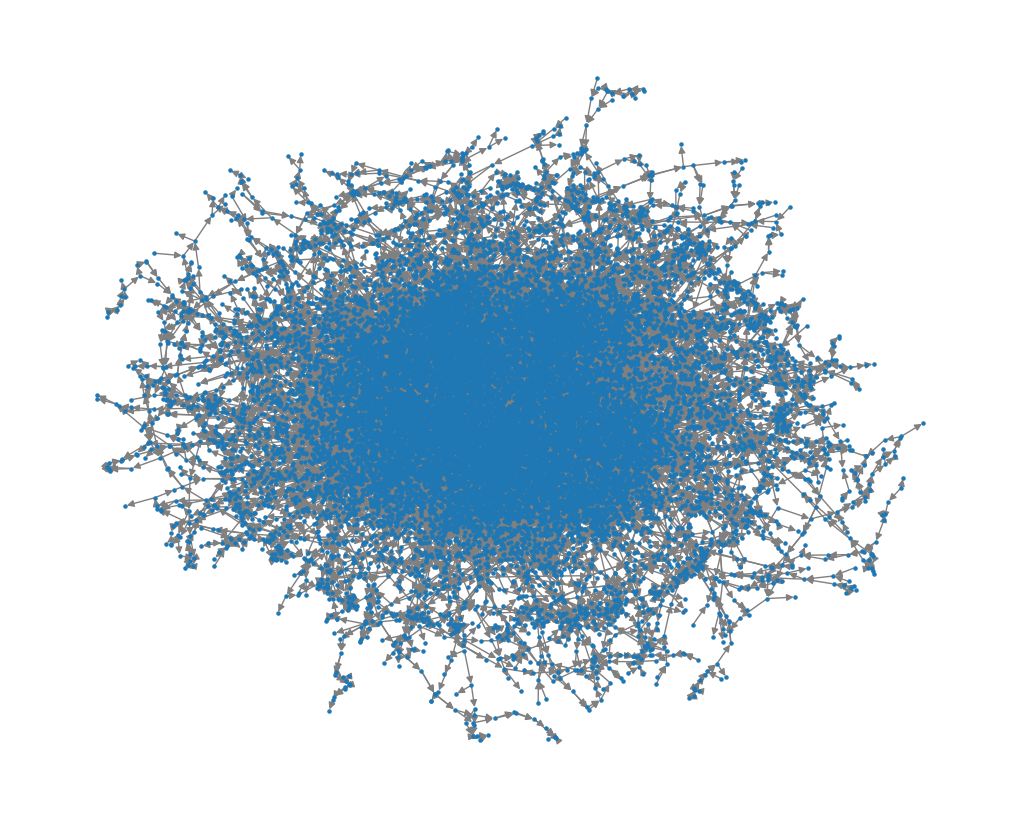

In [5]:
G=nx.DiGraph(edges)
plt.figure(figsize=(10, 8))
nx.draw(G,node_size=5,edge_color='gray')
plt.show()

plot the line ancestry as a directed acyclic graph

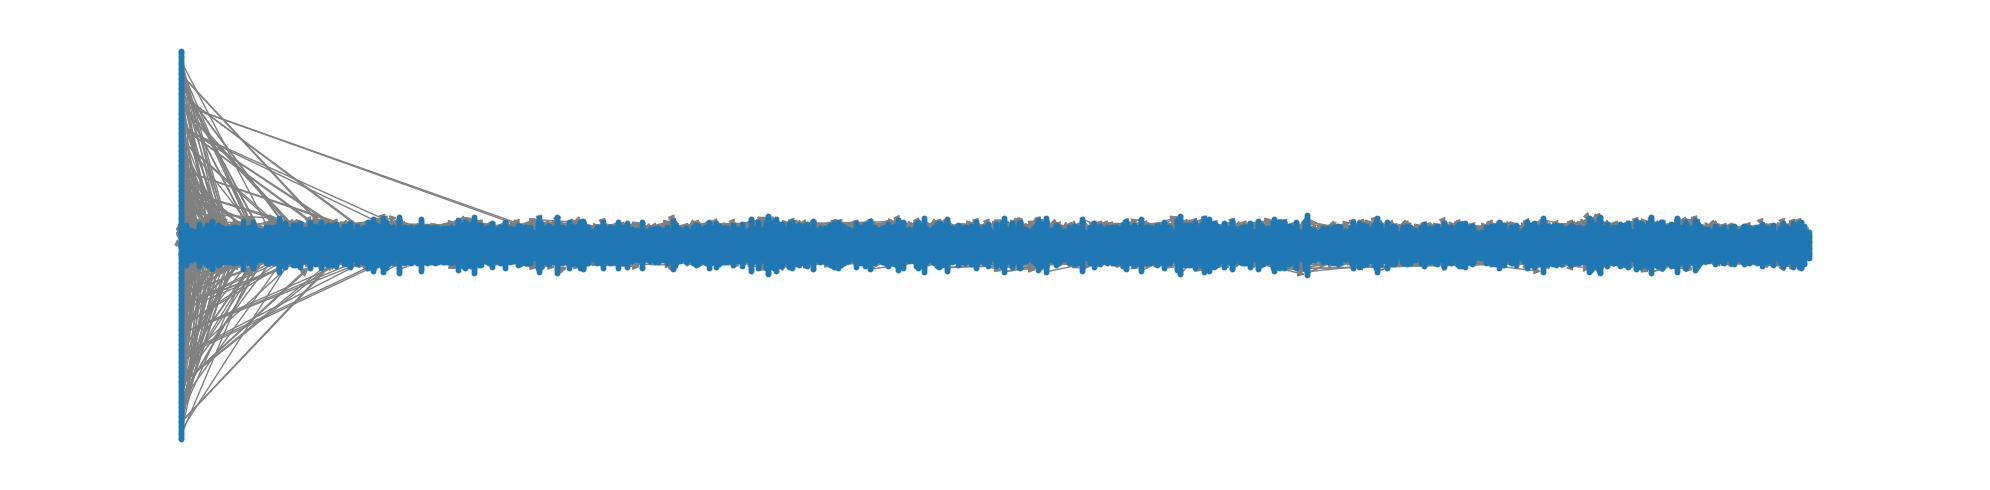

In [6]:
G=nx.DiGraph(edges)

for node in G.nodes:
    for n in range(len(lines)):
        if len(np.where(ids[n]==node)[0])>0:
            break
    G.nodes[node]["birth"] = n

pos = nx.multipartite_layout(G, subset_key="birth", align='vertical')
for key in pos.keys():
    oldval=pos[key]
    newval=np.array([oldval[0],-oldval[1]])
    pos[key]=newval
    
plt.figure(figsize=(20, 5))
nx.draw_networkx(G,pos=pos,with_labels=False,edge_color='gray',node_size=10)

plt.axis("off")
plt.tight_layout()
plt.show()

plot the lines

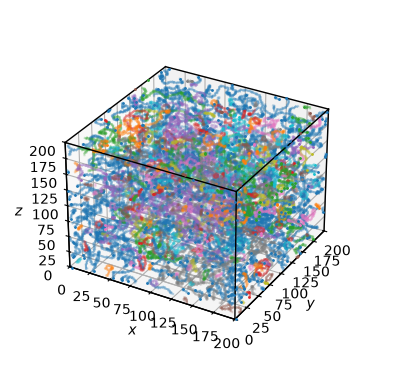

38.27494203625247


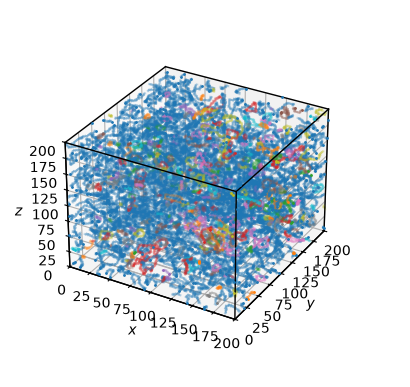

41.190276850014925


In [7]:
faces=None

start=timeit.default_timer()
an.makeplot(0, Ns, Ls, faces=None, lines=lines, cids=cids, show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
an.makeplot(nt-1, Ns, Ls, faces=None, lines=lines, cids=cids, show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

plot the lines alongside the saved faces of the fields

In [8]:
file=open("%sfaces.dat"%(filebase),"rb")
faces=pickle.load(file)
file.close()
Rmax=np.max(faces)

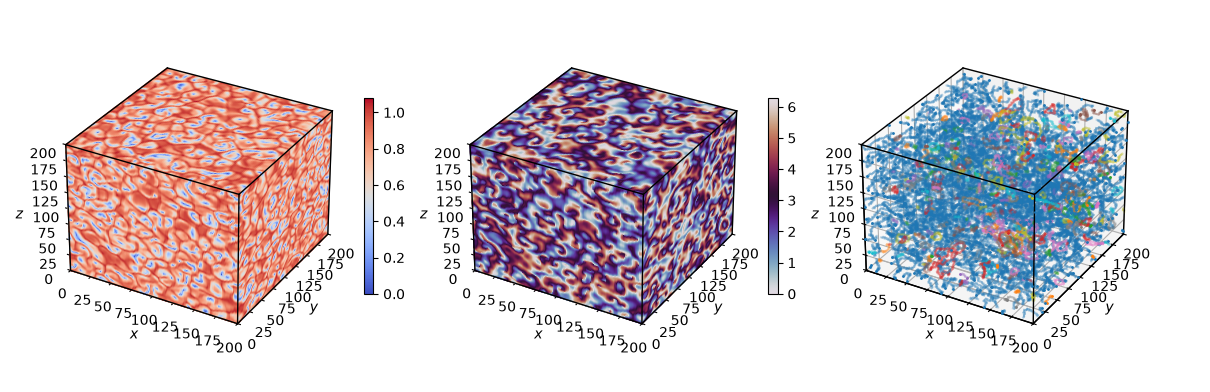

41.07095101522282


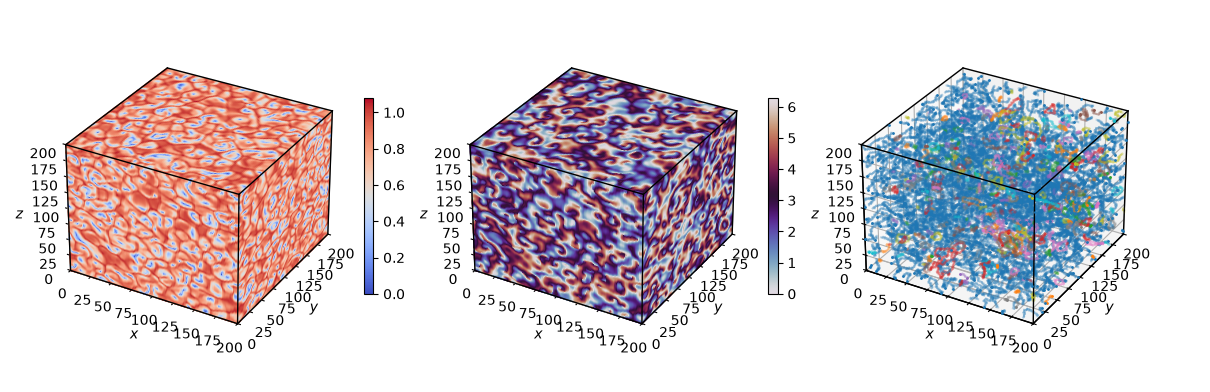

43.875296659301966


In [9]:
start=timeit.default_timer()
an.makeplot(nt-1, Ns, Ls, faces, lines, cids, Rmax, show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
an.makeplot(nt-1, Ns, Ls, faces, lines, cids, Rmax, show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

In [10]:
if os.path.exists('%sanimation.mp4'%(filebase)):
    display(Video('%sanimation.mp4'%(filebase)))